# Lecture 2: Linear Regression

This notebook contains worked examples and computational demonstrations for the companion slides.

[Open in Google Colab](https://colab.research.google.com/github/DrFarrukh/teaching/blob/main/courses/artificial-neural-networks/lectures/lecture-02/notebook.ipynb). Upload the notebook to Google Colab and select **Runtime → Run all**. The examples use synthetic data and need no file uploads.


In [ ]:
# Google Colab includes these packages in its standard runtime.
# Uncomment this line only if a package is missing:
# %pip install torch numpy matplotlib


In [2]:
import math
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

torch.set_num_threads(1)
torch.manual_seed(7)
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.2})


def show_plot(title, xlabel, ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

## Two successive gradient updates

In [3]:
x = torch.tensor([[1.], [2.], [3.]])
y = 2*x + 1
w = torch.zeros(1, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
tiny_history = []
for step in range(3):
    loss = ((x @ w + b - y)**2).mean()
    tiny_history.append([step, w.item(), b.item(), loss.item()])
    if step < 2:
        loss.backward()
        print(f"step {step}: gradients = {w.grad.item():.6f}, {b.grad.item():.6f}")
        with torch.no_grad():
            w -= 0.1*w.grad
            b -= 0.1*b.grad
        w.grad.zero_()
        b.grad.zero_()
print("step, w, b, MSE\n", np.array(tiny_history))
assert np.isclose(tiny_history[2][1], 454/225, atol=1e-6)
assert np.isclose(tiny_history[2][2], 67/75, atol=1e-6)

step 0: gradients = -22.666668, -10.000000
step 1: gradients = 2.488891, 1.066668
step, w, b, MSE
 [[0.00000000e+00 0.00000000e+00 0.00000000e+00 2.76666660e+01]
 [1.00000000e+00 2.26666689e+00 1.00000000e+00 3.31852406e-01]
 [2.00000000e+00 2.01777768e+00 8.93333256e-01 5.26750647e-03]]


## The fitted line across gradient updates

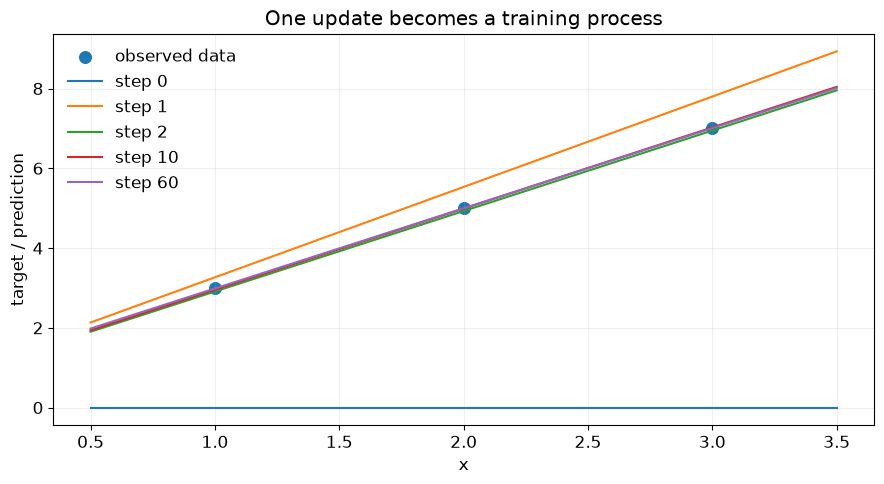

In [4]:
def fit_tiny(lr, steps=40):
    wt = torch.zeros(1, 1, requires_grad=True)
    bt = torch.zeros(1, requires_grad=True)
    records = []
    for step in range(steps + 1):
        loss = ((x @ wt + bt - y)**2).mean()
        records.append([step, wt.item(), bt.item(), loss.item()])
        if not torch.isfinite(loss) or step == steps:
            break
        loss.backward()
        with torch.no_grad():
            wt -= lr*wt.grad
            bt -= lr*bt.grad
        wt.grad.zero_()
        bt.grad.zero_()
    return np.array(records)

trajectory = fit_tiny(0.1, 60)
line_x = np.linspace(0.5, 3.5, 100)
plt.scatter(x.numpy().ravel(), y.numpy().ravel(), s=70, label="observed data")
for step in [0, 1, 2, 10, 60]:
    _, wt, bt, _ = trajectory[step]
    plt.plot(line_x, wt*line_x+bt, label=f"step {step}")
show_plot("One update becomes a training process", "x", "target / prediction")

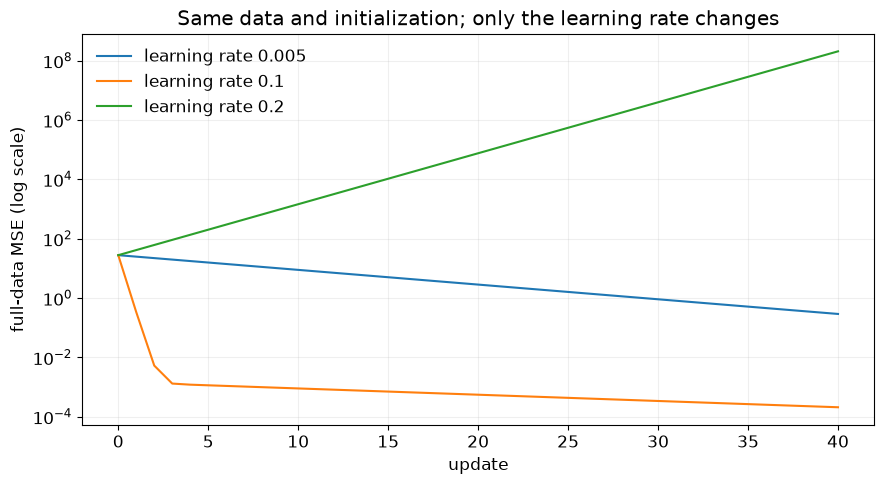

Stable fixed-step interval for this full-batch quadratic: 0 < lr < 0.18029486433300462


In [5]:
rate_histories = {}
for lr in [0.005, 0.1, 0.2]:
    record = fit_tiny(lr, 40)
    rate_histories[str(lr)] = record
    plt.semilogy(record[:, 0], record[:, 3], label=f"learning rate {lr}")
show_plot("Same data and initialization; only the learning rate changes",
          "update", "full-data MSE (log scale)")
# This quadratic has Hessian 2 A.T A / N, with A = [x, 1].
A_tiny = torch.cat([x, torch.ones_like(x)], dim=1)
largest_eigenvalue = torch.linalg.eigvalsh(2*A_tiny.T@A_tiny/len(x)).max().item()
print("Stable fixed-step interval for this full-batch quadratic: 0 < lr <",
      2/largest_eigenvalue)

## A two-feature gradient calculation

In [6]:
X_hand = torch.tensor([[1., 0.], [0., 1.], [1., 1.]])
y_hand = torch.tensor([[3.], [-2.], [0.]])
wh = torch.zeros(2, 1, requires_grad=True)
bh = torch.zeros(1, requires_grad=True)
errors = X_hand@wh+bh-y_hand
loss_hand = (errors**2).mean()
loss_hand.backward()
analytic_w = (2/len(X_hand))*X_hand.T@errors.detach()
analytic_b = 2*errors.detach().mean(dim=0)
torch.testing.assert_close(wh.grad, analytic_w)
torch.testing.assert_close(bh.grad, analytic_b)
print("MSE:", loss_hand.item(), "grad w:", wh.grad.ravel(), "grad b:", bh.grad)
with torch.no_grad():
    wh -= 0.1*wh.grad
    bh -= 0.1*bh.grad
print("updated w:", wh.ravel(), "b:", bh, "MSE:", ((X_hand@wh+bh-y_hand)**2).mean().item())

MSE: 4.333333492279053 grad w: tensor([-2.0000,  1.3333]) grad b: tensor([-0.6667])
updated w: tensor([ 0.2000, -0.1333], grad_fn=<ViewBackward0>) b: tensor([0.0667], requires_grad=True) MSE: 3.7422220706939697


## Synthetic data with known generating parameters

In [7]:
data_generator = torch.Generator().manual_seed(7)
true_w = torch.tensor([[2.], [-3.4]])
true_b = torch.tensor([4.2])
X_all = torch.randn(1280, 2, generator=data_generator)
noise = 0.1*torch.randn(1280, 1, generator=data_generator)
y_all = X_all@true_w+true_b+noise
# IID synthetic rows; fixed split before any model fitting.
X_train, y_train = X_all[:1000], y_all[:1000]
X_val, y_val = X_all[1000:1140], y_all[1000:1140]
X_test, y_test = X_all[1140:], y_all[1140:]
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, "Test:", X_test.shape)
print("Known noise variance:", 0.1**2)

Training: torch.Size([1000, 2]) torch.Size([1000, 1])
Validation: torch.Size([140, 2]) Test: torch.Size([140, 2])
Known noise variance: 0.010000000000000002


In [8]:
def data_iter(batch_size, features, labels, generator):
    indices = torch.randperm(len(features), generator=generator)
    for start in range(0, len(features), batch_size):
        selected = indices[start:start+batch_size]
        yield features[selected], labels[selected]

batch_sizes = [len(xb) for xb, yb in data_iter(
    32, X_train, y_train, torch.Generator().manual_seed(100))]
print("Batches per epoch:", len(batch_sizes), "last batch:", batch_sizes[-1])
assert sum(batch_sizes) == 1000 and batch_sizes[-1] == 8

Batches per epoch: 32 last batch: 8


## From-scratch model, loss, and update

In [9]:
def linear_model(features, weight, bias):
    return features@weight+bias


def mse(prediction, target):
    assert prediction.shape == target.shape, (prediction.shape, target.shape)
    return ((prediction-target)**2).mean()


def sgd(parameters, lr):
    with torch.no_grad():
        for parameter in parameters:
            parameter -= lr*parameter.grad
            parameter.grad.zero_()


init_generator = torch.Generator().manual_seed(11)
initial_w = 0.01*torch.randn(2, 1, generator=init_generator)
initial_b = torch.zeros(1)


def train_scratch(lr=0.03, batch_size=32, epochs=20):
    weight = initial_w.clone().requires_grad_()
    bias = initial_b.clone().requires_grad_()
    shuffle = torch.Generator().manual_seed(100)
    history = []
    for epoch in range(epochs):
        for xb, yb in data_iter(batch_size, X_train, y_train, shuffle):
            loss = mse(linear_model(xb, weight, bias), yb)
            loss.backward()
            sgd([weight, bias], lr)  # loss already averages this batch
        with torch.no_grad():
            train_loss = mse(linear_model(X_train, weight, bias), y_train).item()
            val_loss = mse(linear_model(X_val, weight, bias), y_val).item()
        history.append([epoch+1, train_loss, val_loss])
    return weight.detach(), bias.detach(), np.array(history)

## Training curves and parameter recovery

Generating w: tensor([ 2.0000, -3.4000]) Learned w: tensor([ 2.0019, -3.4062])
Generating b: tensor([4.2000]) Learned b: tensor([4.1990])


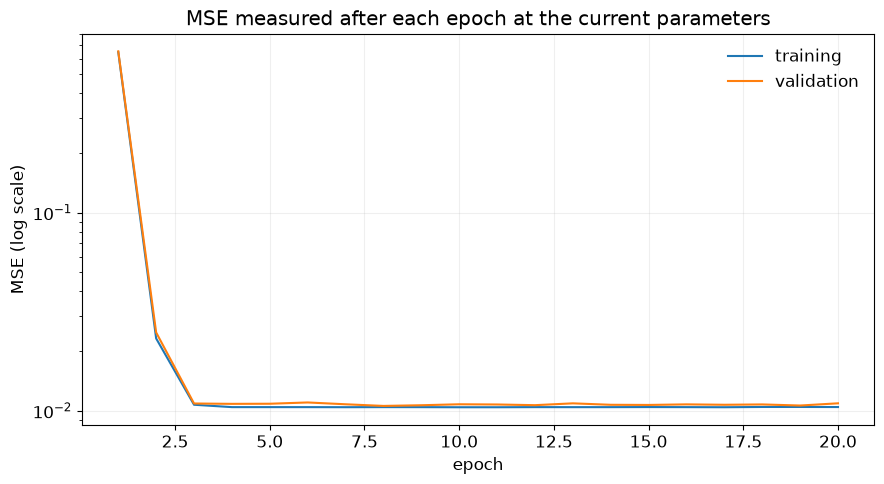

In [10]:
learned_w, learned_b, scratch_history = train_scratch()
print("Generating w:", true_w.ravel(), "Learned w:", learned_w.ravel())
print("Generating b:", true_b, "Learned b:", learned_b)
plt.semilogy(scratch_history[:, 0], scratch_history[:, 1], label="training")
plt.semilogy(scratch_history[:, 0], scratch_history[:, 2], label="validation")
show_plot("MSE measured after each epoch at the current parameters", "epoch", "MSE (log scale)")

## Equivalent implementation with torch.nn

In [11]:
def train_concise(lr=0.03, batch_size=32, epochs=20):
    model = nn.Linear(2, 1)
    with torch.no_grad():
        model.weight.copy_(initial_w.T)
        model.bias.copy_(initial_b)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    shuffle = torch.Generator().manual_seed(100)
    history = []
    for epoch in range(epochs):
        model.train()
        for xb, yb in data_iter(batch_size, X_train, y_train, shuffle):
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            history.append([epoch+1, criterion(model(X_train), y_train).item(),
                            criterion(model(X_val), y_val).item()])
    return model, np.array(history)

model, concise_history = train_concise()
torch.testing.assert_close(model.weight.detach().T, learned_w, atol=2e-5, rtol=2e-5)
torch.testing.assert_close(model.bias.detach(), learned_b, atol=2e-5, rtol=2e-5)
print("Maximum prediction difference:",
      (model(X_val).detach()-(X_val@learned_w+learned_b)).abs().max().item())

Maximum prediction difference: 0.0


## DataLoader is the packaged iterator

DataLoader packages batching. The same integer seed alone does not guarantee the same order as another iterator.

In [12]:
dataset = torch.utils.data.TensorDataset(X_train, y_train)
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True,
                                    generator=torch.Generator().manual_seed(100),
                                    num_workers=0, drop_last=False)
xb, yb = next(iter(loader))
print("DataLoader batch shapes:", xb.shape, yb.shape)
# DataLoader need not produce the same order as our manual iterator for the same seed.
# Exact equivalence above therefore uses the same iterator in both implementations.

DataLoader batch shapes: torch.Size([32, 2]) torch.Size([32, 1])


## Batch size, epochs, and update counts

batch 1: 1000 updates/epoch; 12000 updates in 12 epochs
batch 32: 32 updates/epoch; 384 updates in 12 epochs
batch 1000: 1 updates/epoch; 12 updates in 12 epochs


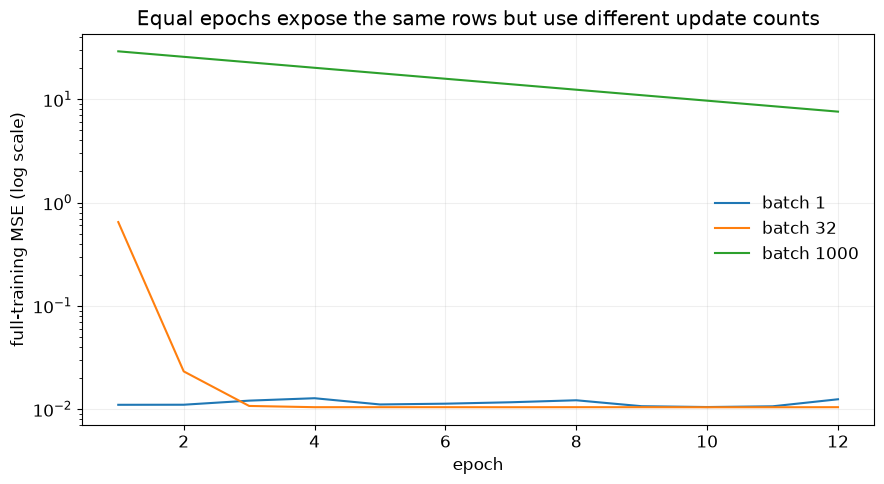

In [13]:
batch_results = {}
for size in [1, 32, 1000]:
    _, _, hist = train_scratch(batch_size=size, epochs=12)
    batch_results[str(size)] = hist
    plt.semilogy(hist[:, 0], hist[:, 1], label=f"batch {size}")
    print(f"batch {size}: {math.ceil(1000/size)} updates/epoch; "
          f"{12*math.ceil(1000/size)} updates in 12 epochs")
show_plot("Equal epochs expose the same rows but use different update counts",
          "epoch", "full-training MSE (log scale)")
# This is NOT an equal-update or equal-wall-clock benchmark.

## Broadcasting and target-shape correctness

In [14]:
pred = torch.tensor([[3.], [5.], [7.]])
target = torch.tensor([3., 5., 7.])
wrong_errors = pred-target
right_errors = pred-target.reshape(-1, 1)
print("Wrong shape:", wrong_errors.shape, "wrong MSE:", (wrong_errors**2).mean().item())
print("Right shape:", right_errors.shape, "right MSE:", (right_errors**2).mean().item())
assert np.isclose((wrong_errors**2).mean().item(), 16/3)

Wrong shape: torch.Size([3, 3]) wrong MSE: 5.333333492279053
Right shape: torch.Size([3, 1]) right MSE: 0.0


## Independent least-squares reference on TRAINING data

This independent training-data reference is available because the model is linear. It does not generalize to arbitrary neural networks.

In [15]:
design = torch.cat([X_train, torch.ones(len(X_train), 1)], dim=1).double()
least_squares = torch.linalg.lstsq(design, y_train.double()).solution
print("Least-squares weights and bias:", least_squares.ravel())
print("SGD weights and bias:", torch.cat([learned_w.ravel(), learned_b]))
# Avoid explicitly forming an inverse of A.T@A.

Least-squares weights and bias: tensor([ 2.0015, -3.4017,  4.2015], dtype=torch.float64)
SGD weights and bias: tensor([ 2.0019, -3.4062,  4.1990])


In [16]:
z = torch.tensor([[-1.], [0.], [1.], [2.]])
X_duplicate = torch.cat([z, z], dim=1)
prediction_a = X_duplicate@torch.tensor([[2.], [3.]])
prediction_b = X_duplicate@torch.tensor([[1.], [4.]])
torch.testing.assert_close(prediction_a, prediction_b)
print("Different weights, identical predictions:", prediction_a.ravel())
print("The data identifies w1+w2=5, not the two coefficients separately.")

Different weights, identical predictions: tensor([-5.,  0.,  5., 10.])
The data identifies w1+w2=5, not the two coefficients separately.


## Multi-output shape check

In [17]:
multi = nn.Linear(2, 3)
print("Input:", X_val.shape, "Weight:", multi.weight.shape,
      "Bias:", multi.bias.shape, "Output:", multi(X_val).shape)
assert multi(X_val).shape == (140, 3)

Input: torch.Size([140, 2]) Weight: torch.Size([3, 2]) Bias: torch.Size([3]) Output: torch.Size([140, 3])


## Held-out evaluation

Test MSE=0.011261; RMSE=0.106116; mean baseline MSE=14.115685


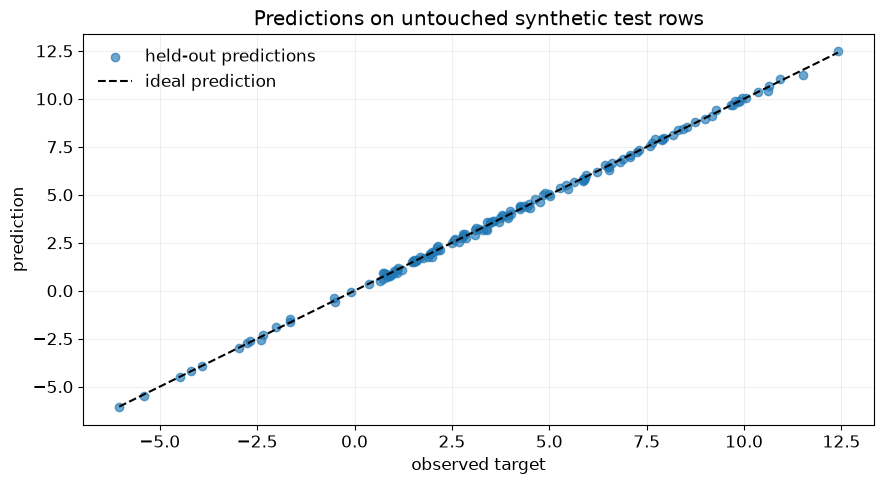

In [18]:
model.eval()
with torch.no_grad():
    test_prediction = model(X_test)
    test_mse = mse(test_prediction, y_test).item()
    test_rmse = math.sqrt(test_mse)
    baseline_mse = ((y_test-y_train.mean())**2).mean().item()
print(f"Test MSE={test_mse:.6f}; RMSE={test_rmse:.6f}; mean baseline MSE={baseline_mse:.6f}")
assert test_mse < 0.03 and test_mse < baseline_mse/20
plt.scatter(y_test.numpy().ravel(), test_prediction.numpy().ravel(), alpha=0.65,
            label="held-out predictions")
limits = [y_test.min().item(), y_test.max().item()]
plt.plot(limits, limits, "k--", label="ideal prediction")
show_plot("Predictions on untouched synthetic test rows", "observed target", "prediction")

In [19]:
# Known generating function evaluated on fresh synthetic draws; no model selection.
noise_results = []
for noise_std in [0., 0.1, 0.5, 1.]:
    g = torch.Generator().manual_seed(99)
    synthetic_error = noise_std*torch.randn(5000, 1, generator=g)
    empirical = (synthetic_error**2).mean().item()
    noise_results.append([noise_std, noise_std**2, empirical])
print("noise std, expected MSE at true model, empirical MSE\n", np.array(noise_results))

noise std, expected MSE at true model, empirical MSE
 [[0.         0.         0.        ]
 [0.1        0.01       0.01000226]
 [0.5        0.25       0.25005645]
 [1.         1.         1.00022578]]
